#### Self Attention


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class SelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super(SelfAttention, self).__init__()
        self.embed_dim = embed_dim

        self.W_q = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_k = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_v = nn.Linear(embed_dim, embed_dim, bias=False)

    def forward(self, x):

        q = self.W_q(x)  # (batch_size, seq_len, embed_dim)
        k = self.W_k(x)  # (batch_size, seq_len, embed_dim)
        v = self.W_v(x)  # (batch_size, seq_len, embed_dim

        dk = self.embed_dim ** 0.5

        score = torch.matmul(q, k.transpose(-2, -1)) / dk
        attn_weights = F.softmax(score, dim = -1)
        output = torch.matmul(attn_weights, v)  # (batch_size, seq_len, embed_dim)

        return output, attn_weights

if __name__ == "__main__":
    # Simulate a sentence of 4 words, where each word is represented by a 512-dimensional vector
    batch_size = 1
    sequence_length = 4
    embed_size = 512
    
    # Create dummy input data
    dummy_input = torch.randn(batch_size, sequence_length, embed_size)
    
    # Initialize the self-attention mechanism
    attention_layer = SelfAttention(embed_size)
    
    # Pass the input through the layer
    output, weights = attention_layer(dummy_input)
    
    print(f"Input shape:  {dummy_input.shape}")
    print(f"Output shape: {output.shape}")    # Should perfectly match the input shape
    print(f"Weights shape: {weights.shape}")  #


Input shape:  torch.Size([1, 4, 512])
Output shape: torch.Size([1, 4, 512])
Weights shape: torch.Size([1, 4, 4])


#### Multi Attention

1. The Setup
    - Imagine we have a tiny sentence with just two words: "The cat".
        - Sequence Length (seq_len): 2 tokens
        - Embedding Dimension (embed_dim): 4 (each word is represented by a list of 4 numbers)
        - Number of Heads (num_heads): 2
    - Because we have 2 heads and an embedding dimension of 4, each head will operate in a smaller sub-space.
        - Head Dimension (head_dim): $4 \div 2 = 2$ dimensions per head.

2. Step 1: The Input Embeddings
    - First, the words are converted into their embedding vectors. 

3. Step 2: The Linear Projections
    - Before dividing anything, the model multiplies this input by learned weight matrices to create the Queries ($Q$), Keys ($K$), and Values ($V$).Let's just look at the Query ($Q$) matrix to keep things simple. Assume after multiplying by the $W^Q$ weights.

4.  The Split (How the "Heads" are created)
    - Here is where the magic happens. PyTorch doesn't send "The" to Head 1 and "cat" to Head 2. Instead, it literally chops the 4-dimensional Query vector for each word in half.

5. Step 4: Independent Attention
    - Now, the heads operate completely independently:
        - Head 1 calculates attention scores using only its 2D slice [10, 11] and [20, 21]. It might learn that this specific slice of the data is great for tracking syntax (e.g., nouns following articles).
        - Head 2 calculates its own completely separate attention scores using its 2D slice [12, 13] and [22, 23]. It might learn that this slice of the data is great for tracking tone or context.

6. Step 5: The Reunion (Concatenation)
    - Once both heads have finished computing their new, updated Value vectors, the model glues them back together.
    - If Head 1 outputs [A, B] for the word "The", and Head 2 outputs [C, D] for the word "The", the model concatenates them back into a single 4-dimensional vector: [A, B, C, D]. Finally, it passes that combined vector through one last linear layer to mix the insights from both heads together.Summary

Input shape: torch.Size([2, 10, 512])
Output shape: torch.Size([2, 10, 512])
Attention weights shape: torch.Size([2, 8, 10, 10])


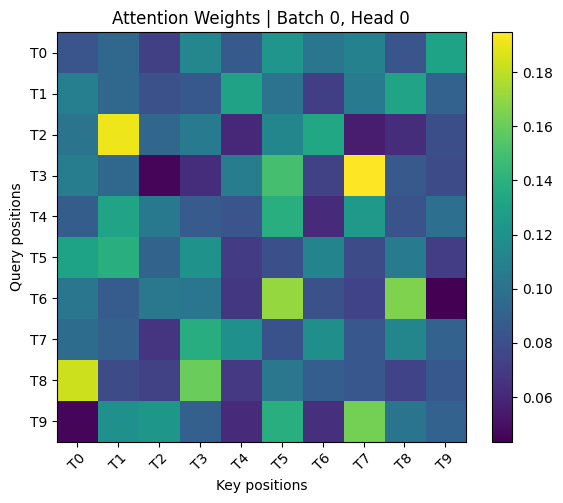

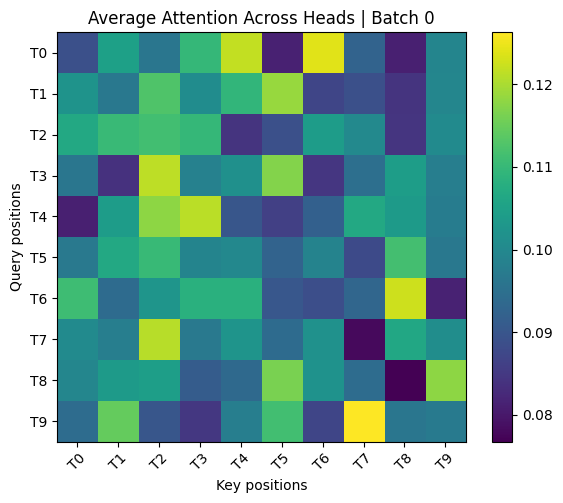

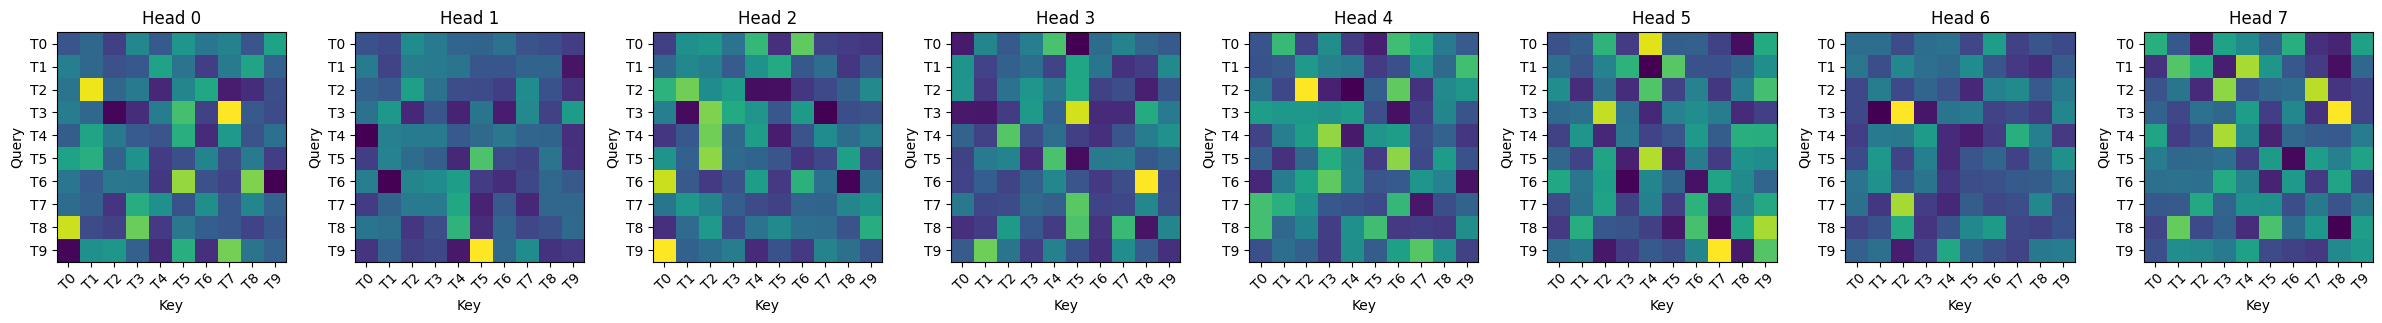

In [4]:
import torch
import torch.nn as nn
import math
import torch.nn.functional as F
import matplotlib.pyplot as plt


class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads

        assert embed_dim % num_heads == 0, "Embedding dimension must be divisible by number of heads"

        self.head_dim = embed_dim // num_heads

        self.w_q = nn.Linear(embed_dim, embed_dim, bias=False)
        self.w_k = nn.Linear(embed_dim, embed_dim, bias=False)
        self.w_v = nn.Linear(embed_dim, embed_dim, bias=False)

        self.w_o = nn.Linear(embed_dim, embed_dim, bias=False)

    def forward(self, q, k, v, mask=None):
        batch_size, q_len, embed_dim = q.size()
        _, k_len, _ = k.size()
        _, v_len, _ = v.size()

        q = self.w_q(q)  # (batch_size, q_len, embed_dim)
        k = self.w_k(k)  # (batch_size, k_len, embed_dim)
        v = self.w_v(v)  # (batch_size, v_len, embed_dim)

        q = q.view(batch_size, q_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(batch_size, k_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(batch_size, v_len, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        # scores shape: (batch_size, num_heads, q_len, k_len)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn_weights = F.softmax(scores, dim=-1)
        attn_output = torch.matmul(attn_weights, v)

        output = attn_output.transpose(1, 2).contiguous().view(batch_size, q_len, embed_dim)
        output = self.w_o(output)

        return output, attn_weights


def plot_attention_head(attn_weights, batch_idx=0, head_idx=0, token_labels=None):
    """
    Plot attention for one batch and one head.
    attn_weights shape: (batch_size, num_heads, seq_len, seq_len)
    """
    attn = attn_weights[batch_idx, head_idx].detach().cpu().numpy()

    plt.figure(figsize=(6, 5))
    plt.imshow(attn)
    plt.colorbar()
    plt.title(f"Attention Weights | Batch {batch_idx}, Head {head_idx}")
    plt.xlabel("Key positions")
    plt.ylabel("Query positions")

    if token_labels is not None:
        plt.xticks(range(len(token_labels)), token_labels, rotation=45)
        plt.yticks(range(len(token_labels)), token_labels)

    plt.tight_layout()
    plt.show()


def plot_average_attention(attn_weights, batch_idx=0, token_labels=None):
    """
    Plot average attention across all heads for one batch.
    """
    avg_attn = attn_weights[batch_idx].mean(dim=0).detach().cpu().numpy()

    plt.figure(figsize=(6, 5))
    plt.imshow(avg_attn)
    plt.colorbar()
    plt.title(f"Average Attention Across Heads | Batch {batch_idx}")
    plt.xlabel("Key positions")
    plt.ylabel("Query positions")

    if token_labels is not None:
        plt.xticks(range(len(token_labels)), token_labels, rotation=45)
        plt.yticks(range(len(token_labels)), token_labels)

    plt.tight_layout()
    plt.show()

def plot_all_heads(attn_weights, batch_idx=0, token_labels=None):
    num_heads = attn_weights.size(1)
    fig, axes = plt.subplots(1, num_heads, figsize=(3 * num_heads, 3))

    if num_heads == 1:
        axes = [axes]

    for h in range(num_heads):
        attn = attn_weights[batch_idx, h].detach().cpu().numpy()
        axes[h].imshow(attn)
        axes[h].set_title(f"Head {h}")
        axes[h].set_xlabel("Key")
        axes[h].set_ylabel("Query")

        if token_labels is not None:
            axes[h].set_xticks(range(len(token_labels)))
            axes[h].set_yticks(range(len(token_labels)))
            axes[h].set_xticklabels(token_labels, rotation=45)
            axes[h].set_yticklabels(token_labels)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    batch_size = 2
    seq_len = 10
    embed_dim = 512
    num_heads = 8

    x = torch.randn(batch_size, seq_len, embed_dim)

    mha = MultiHeadAttention(embed_dim, num_heads)

    output, attn_weights = mha(x, x, x)

    print(f"Input shape: {x.shape}")
    print(f"Output shape: {output.shape}")   # Should match input shape
    print(f"Attention weights shape: {attn_weights.shape}")  # (batch_size, num_heads, seq_len, seq_len)

    # Optional labels for sequence positions
    token_labels = [f"T{i}" for i in range(seq_len)]

    # Visualize one head
    plot_attention_head(attn_weights, batch_idx=0, head_idx=0, token_labels=token_labels)

    # Visualize average attention across all heads
    plot_average_attention(attn_weights, batch_idx=0, token_labels=token_labels)

    plot_all_heads(attn_weights, batch_idx=0, token_labels=token_labels)